In [ ]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Transformation for 1 link / joint
def DH_proximal(alpha, a, d, theta):
    """
    Calculate the proximal DH transformation matrix for a robotic arm link.

    :param theta: Joint angle (in radians)
    :param d: Offset along the previous z-axis
    :param alpha: Angle about the common normal
    :param a: Length of the common normal (offset along the previous x-axis)
    :return: 4x4 transformation matrix
    """
    deg2rad = np.pi/180.0
    alpha = alpha * deg2rad
    theta = theta * deg2rad
    return np.array([
        [np.cos(theta), -np.sin(theta), 0, a],
        [np.sin(theta) * np.cos(alpha), np.cos(theta) * np.cos(alpha), -np.sin(alpha), -d * np.sin(alpha)],
        [np.sin(theta) * np.sin(alpha), np.cos(theta) * np.sin(alpha), np.cos(alpha), d * np.cos(alpha)],
        [0, 0, 0, 1]
    ])

# Define the robot arm, notice that RAVEN has offset between kinematic thetas and j_pos in ravenstate
# Joint position should be given in deg or mm
def raven_arm(jpos):
  # DH_proximal(alpha, a, d, theta)
  th1 = jpos[0] + 205
  th2 = jpos[1] + 180
  d3 = jpos[2]
  th4 = jpos[3]
  th5 = jpos[4] - 90
  th6 = 0.5*jpos[6] - 0.5*jpos[5]

  T01 = DH_proximal(0,            0,         0,          th1)
  T12 = DH_proximal(75,           0,         0,          th2)
  T23 = DH_proximal(180.0-52.0,   0,         d3,         90.0)
  T34 = DH_proximal(0,            0,         -470.0,      th4)
  T45 = DH_proximal(90.0,         0,         0,          th5)
  T56 = DH_proximal(90.0,        13,         0,          th6)

  T06 = T01.dot(T12).dot(T23).dot(T34).dot(T45).dot(T56)
  return T06

In [ ]:
num_samples = 30000
num_edge_samples = 10000

# define joint limits
lim_j1 = (20, 60)  # deg
lim_j2 = (55, 110)  # deg
lim_j3 = (330, 420)  # mm
lim_j4 = (0, 360)  # deg
lim_j5 = (-90, 90)  # deg
lim_j6 = (0, 90)  # deg
lim_j7 = (0, 90)  # deg


# initialize end-effector positions
ee_loc_fm0 = np.ones((num_samples, 4))

for i in range(num_samples):
  ee_loc_fm0[i, 0:3] =  raven_arm([random.uniform(lim_j1[0], lim_j1[1]),
                                     random.uniform(lim_j2[0], lim_j2[1]),
                                     random.uniform(lim_j3[0], lim_j3[1]),
                                     random.uniform(lim_j4[0], lim_j4[1]),
                                     random.uniform(lim_j5[0], lim_j5[1]),
                                     random.uniform(lim_j6[0], lim_j6[1]),
                                     random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]

# for RAVEN, this transform is to convert from RAVEN's frame 0 (located in the intersection of the first 3 joint axis) to the Base frame (located on RAVEN's base among the bolts, details can be found the kinematics analysis)
T_0B = np.array([[0, 0, 1, 300.71],
                 [0, -1, 0, 61],
                 [1, 0, 0, -7],
                 [0, 0, 0, 1]])

# convert the simulated points from frame 0 to the Base frame.
ee_loc_fmB = T_0B.dot(ee_loc_fm0.T).T

#|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
# For RAVEN specifically, create edge points
#---------------------------------------------------------
# J1 - J2
#----------------------------------------------------------
# J1 lower limit, J2 lower limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[0],
                                              lim_j2[0],
                                              random.uniform(lim_j3[0], lim_j3[1]),
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]

ee_edge_J12_loc_fm0 = ee_edge_loc_fm0_temp  # first call
#---------------------------------------------------------
# J1 lower limit, J2 upper limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[0],
                                              lim_j2[1],
                                              random.uniform(lim_j3[0], lim_j3[1]),
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J12_loc_fm0 = np.vstack([ee_edge_J12_loc_fm0, ee_edge_loc_fm0_temp])

#---------------------------------------------------------
# J1 upper limit, J2 lower limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[1],
                                              lim_j2[0],
                                              random.uniform(lim_j3[0], lim_j3[1]),
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J12_loc_fm0 = np.vstack([ee_edge_J12_loc_fm0, ee_edge_loc_fm0_temp])

#---------------------------------------------------------
# J1 upper limit, J2 upper limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[1],
                                              lim_j2[1],
                                              random.uniform(lim_j3[0], lim_j3[1]),
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J12_loc_fm0 = np.vstack([ee_edge_J12_loc_fm0, ee_edge_loc_fm0_temp])



ee_edge_J12_loc_fmB = T_0B.dot(ee_edge_J12_loc_fm0.T).T

#---------------------------------------------------------
# J2 - J3
#---------------------------------------------------------
# J2 lower limit, J3 lower limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([random.uniform(lim_j1[0], lim_j1[1]),
                                              lim_j2[0],
                                              lim_j3[0],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]

ee_edge_J23_loc_fm0 = ee_edge_loc_fm0_temp  # first call

# J2 lower limit, J3 upper limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([random.uniform(lim_j1[0], lim_j1[1]),
                                              lim_j2[0],
                                              lim_j3[1],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J23_loc_fm0 = np.vstack([ee_edge_J23_loc_fm0, ee_edge_loc_fm0_temp])

#---------------------------------------------------------
# J2 upper limit, J3 lower limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([random.uniform(lim_j1[0], lim_j1[1]),
                                              lim_j2[1],
                                              lim_j3[0],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J23_loc_fm0 = np.vstack([ee_edge_J23_loc_fm0, ee_edge_loc_fm0_temp])

#---------------------------------------------------------
# J2 upper limit, J3 upper limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([random.uniform(lim_j1[0], lim_j1[1]),
                                              lim_j2[1],
                                              lim_j3[1],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J23_loc_fm0 = np.vstack([ee_edge_J23_loc_fm0, ee_edge_loc_fm0_temp])

ee_edge_J23_loc_fmB = T_0B.dot(ee_edge_J23_loc_fm0.T).T


#---------------------------------------------------------
# J1 - J3
#---------------------------------------------------------
# J1 lower limit, J3 lower limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[0],
                                              random.uniform(lim_j2[0], lim_j2[1]),
                                              lim_j3[0],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]

ee_edge_J13_loc_fm0 = ee_edge_loc_fm0_temp  # first call

# J1 lower limit, J3 upper limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[0],
                                              random.uniform(lim_j2[0], lim_j2[1]),
                                              lim_j3[1],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J13_loc_fm0 = np.vstack([ee_edge_J13_loc_fm0, ee_edge_loc_fm0_temp])

#---------------------------------------------------------
# J1 upper limit, J3 lower limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[1],
                                              random.uniform(lim_j2[0], lim_j2[1]),
                                              lim_j3[0],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J13_loc_fm0 = np.vstack([ee_edge_J13_loc_fm0, ee_edge_loc_fm0_temp])

#---------------------------------------------------------
# J1 upper limit, J3 upper limit
ee_edge_loc_fm0_temp = np.ones((num_edge_samples, 4))
for i in range(num_edge_samples):
  ee_edge_loc_fm0_temp[i, 0:3] =  raven_arm([lim_j1[1],
                                              random.uniform(lim_j2[0], lim_j2[1]),
                                              lim_j3[1],
                                              random.uniform(lim_j4[0], lim_j4[1]),
                                              random.uniform(lim_j5[0], lim_j5[1]),
                                              random.uniform(lim_j6[0], lim_j6[1]),
                                              random.uniform(lim_j7[0], lim_j7[1]),])[0:3, 3]
ee_edge_J13_loc_fm0 = np.vstack([ee_edge_J13_loc_fm0, ee_edge_loc_fm0_temp])

ee_edge_J13_loc_fmB = T_0B.dot(ee_edge_J13_loc_fm0.T).T



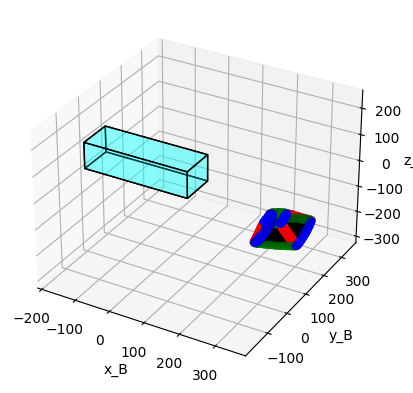

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# draw point cloud of RAVEN workspace
ax.scatter(ee_loc_fmB[:,0], ee_loc_fmB[:,1], ee_loc_fmB[:,2], s=1.0, c = 'k')

# draw edge points of RAVEN workspace
ax.scatter(ee_edge_J12_loc_fmB[:,0], ee_edge_J12_loc_fmB[:,1], ee_edge_J12_loc_fmB[:,2], s=0.001, c='r', label = 'Edge J1-J2')
ax.scatter(ee_edge_J23_loc_fmB[:,0], ee_edge_J23_loc_fmB[:,1], ee_edge_J23_loc_fmB[:,2], s=0.001, c='b', label = 'Edge J2-J3')
ax.scatter(ee_edge_J13_loc_fmB[:,0], ee_edge_J13_loc_fmB[:,1], ee_edge_J13_loc_fmB[:,2], s=0.001, c='g', label = 'Edge J1-J3')

ax.set_xlabel('x_B')
ax.set_ylabel('y_B')
ax.set_zlabel('z_B')



# draw a cuboid to represent RAVEN base
corners = np.array([
    [100, 0, 0],  # Corner 1
    [100, 100, 0],  # Corner 2
    [-200, 100, 0],  # Corner 3
    [-200, 0, 0],  # Corner 4
    [100, 0, 100],  # Corner 5
    [100, 100, 100],  # Corner 6
    [-200, 100, 100],  # Corner 7
    [-200, 0, 100],  # Corner 8
])

faces = [
    [corners[i] for i in [0, 1, 2, 3]],
    [corners[i] for i in [4, 5, 6, 7]],
    [corners[i] for i in [0, 3, 7, 4]],
    [corners[i] for i in [1, 2, 6, 5]],
    [corners[i] for i in [0, 1, 5, 4]],
    [corners[i] for i in [2, 3, 7, 6]]
]


# Plot the faces
ax.add_collection3d(Poly3DCollection(faces, facecolors='cyan', linewidths=1, edgecolors='k', alpha=.25))

# Auto scale to the mesh size
# scale = corners.flatten()
# ax.auto_scale_xyz(scale, scale, scale)

all_points = np.concatenate((corners, ee_loc_fmB[:, 0:3]), axis=0)
min_limit = np.min(all_points, axis=0)
max_limit = np.max(all_points, axis=0)

# Set the axis limits
ax.set_xlim([min_limit[0], max_limit[0]])
ax.set_ylim([min_limit[1], max_limit[1]])
ax.set_zlim([min_limit[2], max_limit[2]])

# Calculate the extents and the range of each axis
extents = np.array([getattr(ax, 'get_{}lim'.format(dim))() for dim in 'xyz'])
ranges = extents[:, 1] - extents[:, 0]

# Determine the maximum range
max_range = np.max(ranges)

# Calculate the center of each axis
centers = np.mean(extents, axis=1)

# Set the same range for each axis centered around the respective centers
for axis, center in zip('xyz', centers):
    getattr(ax, 'set_{}lim'.format(axis))(center - max_range / 2, center + max_range / 2)

plt.show()